In [1]:
# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive

drive.mount('/content/drive')

print("✅ Drive mounted.")

Mounted at /content/drive
✅ Drive mounted.


In [2]:
# =========================================================
# INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install -q faiss-cpu
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


In [3]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

import torch

import faiss

import open_clip

print("✅ Libraries imported.")

✅ Libraries imported.


In [4]:
# =========================================================
# CONFIG
# =========================================================

PROJECT_ROOT = "/content/drive/MyDrive/PersonalFashionStylistV2"

CONFIG = {

    "embeddings_path": os.path.join(
        PROJECT_ROOT,
        "embeddings",
        "clip_embeddings.npy"
    ),

    "metadata_path": os.path.join(
        PROJECT_ROOT,
        "embeddings",
        "embedding_metadata.csv"
    ),

    "faiss_index_path": os.path.join(
        PROJECT_ROOT,
        "faiss",
        "fashion_faiss.index"
    ),

    "top_k": 5
}

print("✅ Config initialized.")

✅ Config initialized.


In [5]:
# =========================================================
# LOAD EMBEDDINGS
# =========================================================

embeddings = np.load(
    CONFIG["embeddings_path"]
)

print("✅ Embeddings loaded.")

print("Shape:", embeddings.shape)

✅ Embeddings loaded.
Shape: (44074, 512)


In [6]:
# =========================================================
# LOAD METADATA
# =========================================================

metadata_df = pd.read_csv(
    CONFIG["metadata_path"]
)

print("✅ Metadata loaded.")

print("Items:", len(metadata_df))

✅ Metadata loaded.
Items: 44074


In [31]:
# =========================================================
# REDOWNLOAD FASHION PRODUCT DATASET
# =========================================================

import kagglehub

fashion_products_path = kagglehub.dataset_download(
    "paramaggarwal/fashion-product-images-small"
)

print("✅ Dataset downloaded.")

print(fashion_products_path)

100%|██████████| 565M/565M [00:06<00:00, 98.6MB/s]

Extracting files...


✅ Dataset downloaded.
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1


In [33]:
# =========================================================
# FIX METADATA IMAGE PATHS
# =========================================================

real_image_dir = os.path.join(
    fashion_products_path,
    "images"
)

def fix_inventory_path(old_path):

    filename = os.path.basename(old_path)

    return os.path.join(
        real_image_dir,
        filename
    )

metadata_df["image_path"] = metadata_df["image_path"].apply(
    fix_inventory_path
)

print("✅ Metadata paths fixed.")

✅ Metadata paths fixed.


In [34]:
sample_path = metadata_df.iloc[0]["image_path"]

print(sample_path)

print(os.path.exists(sample_path))

/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1/images/15970.jpg
True


In [35]:
# =========================================================
# VERIFY ALIGNMENT
# =========================================================

assert len(metadata_df) == len(embeddings)

print("✅ Embedding-metadata alignment verified.")

✅ Embedding-metadata alignment verified.


In [42]:
# =========================================================
# BUILD FAISS INDEX
# =========================================================

embedding_dim = embeddings.shape[1]

index = faiss.IndexFlatIP(
    embedding_dim
)

index.add(
    embeddings.astype(np.float32)
)

print("✅ FAISS index built.")

print("Total Indexed Vectors:",
      index.ntotal)

✅ FAISS index built.
Total Indexed Vectors: 44074


In [43]:
# =========================================================
# SAVE FAISS INDEX
# =========================================================

faiss.write_index(

    index,

    CONFIG["faiss_index_path"]
)

print("✅ FAISS index saved.")

print(CONFIG["faiss_index_path"])

✅ FAISS index saved.
/content/drive/MyDrive/PersonalFashionStylistV2/faiss/fashion_faiss.index


In [44]:
# =========================================================
# DEVICE SETUP
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("✅ Device:", device)

✅ Device: cuda


In [45]:
# =========================================================
# LOAD OPENCLIP MODEL
# =========================================================

model, _, preprocess = open_clip.create_model_and_transforms(

    "ViT-B-32",

    pretrained="laion2b_s34b_b79k"
)

model = model.to(device)

model.eval()

print("✅ OpenCLIP loaded.")

✅ OpenCLIP loaded.


In [46]:
# =========================================================
# QUERY IMAGE EMBEDDING FUNCTION
# =========================================================

def generate_query_embedding(image_path):

    image = Image.open(image_path).convert("RGB")

    image = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():

        embedding = model.encode_image(image)

        embedding = embedding / embedding.norm(
            dim=-1,
            keepdim=True
        )

    embedding = embedding.cpu().numpy()

    return embedding

In [47]:
# =========================================================
# RETRIEVE SIMILAR ITEMS
# =========================================================

def retrieve_similar_items(

    query_image_path,

    top_k=5
):

    # Generate query embedding
    query_embedding = generate_query_embedding(
        query_image_path
    )

    # Search FAISS index
    similarities, indices = index.search(
        query_embedding.astype(np.float32),
        top_k
    )

    results = metadata_df.iloc[
        indices[0]
    ]

    return results, similarities[0]

In [48]:
# =========================================================
# TEST QUERY IMAGE
# =========================================================

query_image_path = metadata_df.iloc[100]["image_path"]

print("✅ Query Image:")

print(query_image_path)

✅ Query Image:
/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1/images/19311.jpg


In [49]:
# =========================================================
# RUN SIMILARITY SEARCH
# =========================================================

results, similarities = retrieve_similar_items(

    query_image_path,

    top_k=CONFIG["top_k"]
)

print("✅ Retrieval complete.")

results

✅ Retrieval complete.


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,image_path
100,19311,Men,Footwear,Shoes,Casual Shoes,White,Fall,Casual,/root/.cache/kagglehub/datasets/paramaggarwal/...
1686,31941,Women,Footwear,Shoes,Casual Shoes,Grey,Summer,Casual,/root/.cache/kagglehub/datasets/paramaggarwal/...
15499,15881,Unisex,Footwear,Shoes,Casual Shoes,Grey,Winter,Casual,/root/.cache/kagglehub/datasets/paramaggarwal/...
26104,28603,Women,Footwear,Shoes,Sports Shoes,Black,Summer,Sports,/root/.cache/kagglehub/datasets/paramaggarwal/...
14871,38761,Women,Footwear,Shoes,Sports Shoes,Grey,Summer,Sports,/root/.cache/kagglehub/datasets/paramaggarwal/...


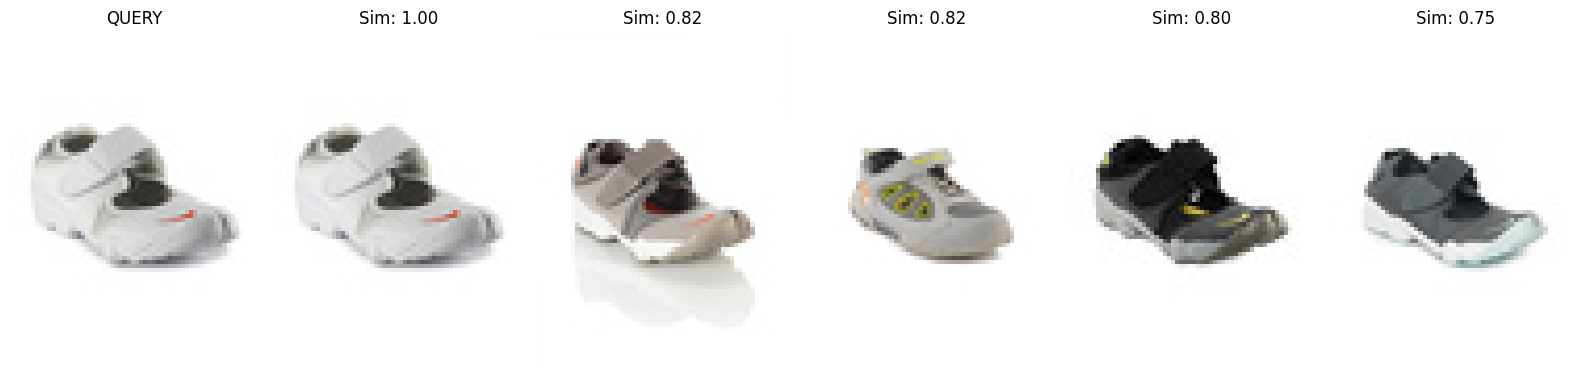

In [50]:
# =========================================================
# VISUALIZE QUERY + RESULTS
# =========================================================

plt.figure(figsize=(16, 4))

# ==========================
# SHOW QUERY IMAGE
# ==========================

query_image = Image.open(
    query_image_path
).convert("RGB")

plt.subplot(1, CONFIG["top_k"] + 1, 1)

plt.imshow(query_image)

plt.title("QUERY")

plt.axis("off")

# ==========================
# SHOW RETRIEVED IMAGES
# ==========================

for i in range(CONFIG["top_k"]):

    row = results.iloc[i]

    result_image = Image.open(
        row["image_path"]
    ).convert("RGB")

    similarity = similarities[i]

    plt.subplot(
        1,
        CONFIG["top_k"] + 1,
        i + 2
    )

    plt.imshow(result_image)

    plt.title(
        f"Sim: {similarity:.2f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [55]:
# =========================================================
# UPLOAD CUSTOM QUERY IMAGE
# =========================================================

from google.colab import files

uploaded = files.upload()

Saving images.jpg to images.jpg


In [56]:
# =========================================================
# SET CUSTOM QUERY IMAGE
# =========================================================

query_image_path = list(uploaded.keys())[0]

print("✅ Query Image Selected:")

print(query_image_path)

✅ Query Image Selected:
images.jpg


In [58]:
# =========================================================
# RUN CUSTOM IMAGE RETRIEVAL
# =========================================================

results, similarities = retrieve_similar_items(

    query_image_path,

    top_k=CONFIG["top_k"]
)

print("✅ Retrieval complete.")

results.head()

✅ Retrieval complete.


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,image_path
34657,1754,Men,Apparel,Topwear,Tshirts,Black,Fall,Sports,/root/.cache/kagglehub/datasets/paramaggarwal/...
33905,1535,Unisex,Accessories,Headwear,Caps,Black,Fall,Sports,/root/.cache/kagglehub/datasets/paramaggarwal/...
31267,1588,Men,Apparel,Topwear,Tshirts,White,Fall,Casual,/root/.cache/kagglehub/datasets/paramaggarwal/...
35282,3469,Unisex,Accessories,Headwear,Headband,Black,Fall,Sports,/root/.cache/kagglehub/datasets/paramaggarwal/...
7938,1577,Unisex,Accessories,Headwear,Caps,Green,Fall,Sports,/root/.cache/kagglehub/datasets/paramaggarwal/...


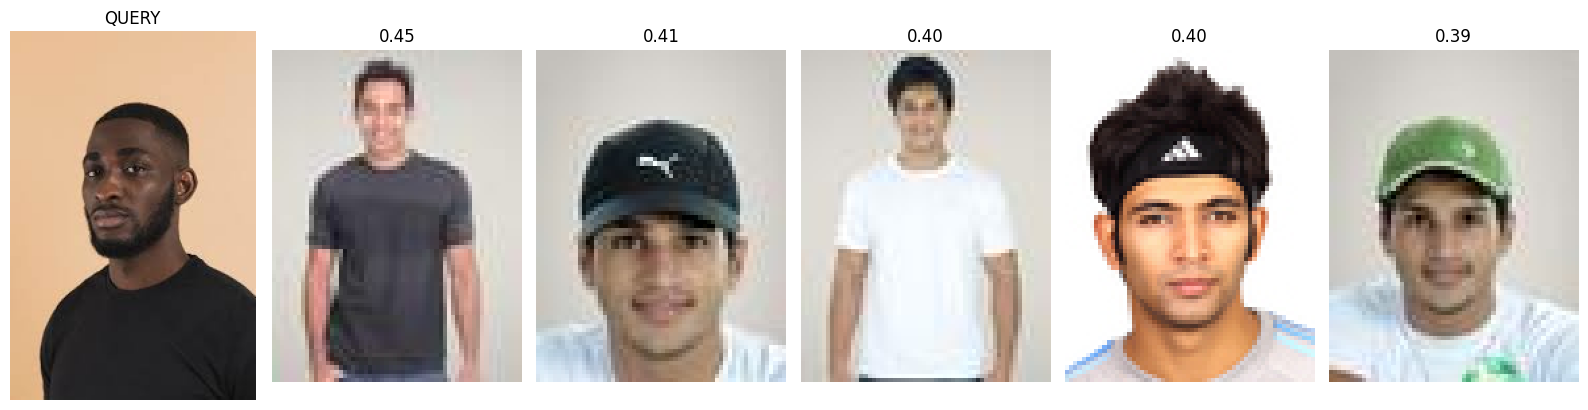

In [59]:
# =========================================================
# VISUALIZE CUSTOM RETRIEVAL RESULTS
# =========================================================

plt.figure(figsize=(16, 4))

# ==========================
# SHOW QUERY IMAGE
# ==========================

query_image = Image.open(
    query_image_path
).convert("RGB")

plt.subplot(1, CONFIG["top_k"] + 1, 1)

plt.imshow(query_image)

plt.title("QUERY")

plt.axis("off")

# ==========================
# SHOW RETRIEVED RESULTS
# ==========================

for i in range(CONFIG["top_k"]):

    row = results.iloc[i]

    result_image = Image.open(
        row["image_path"]
    ).convert("RGB")

    similarity = similarities[i]

    plt.subplot(
        1,
        CONFIG["top_k"] + 1,
        i + 2
    )

    plt.imshow(result_image)

    plt.title(
        f"{similarity:.2f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()